# Porta CNOT in MBQC
su un cluster a T di quattro qubit

## Riferimenti

- R. Raussendorf e H. J. Briegel, *A One-Way Quantum Computer*, **Physical Review Letters** 86, 5188–5191 (2001), [DOI](https://doi.org/10.1103/PhysRevLett.86.5188).
- R. Raussendorf, D. E. Browne e H. J. Briegel, *Measurement-based quantum computation on cluster states*, **Physical Review A** 68, 022312 (2003), [DOI](https://doi.org/10.1103/PhysRevA.68.022312).

## Preparazione dell'ambiente

La cella seguente installa le dipendenze utilizzate in questo notebook.  
Al primo utilizzo potrebbe essere necessario riavviare il kernel dopo l'installazione.

Su Google Colab, il setup scarica il repository (branch `main`) e seleziona la cartella dell’esempio prima di installare le dipendenze. Se richiesto, riavvia la sessione e riesegui le celle. Il clone viene riutilizzato nella stessa sessione; per scaricare aggiornamenti da GitHub, avvia una nuova sessione Colab.


In [ ]:
from pathlib import Path
import os
import subprocess

try:
    import google.colab
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    repository = Path("/content/mbqc-codes")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "main",
            "https://github.com/AlbertoMiserendino/mbqc-codes.git",
            str(repository),
        ], check=True)
    os.chdir(repository / "03-mbqc-cnot")

%pip install -r "../requirements.txt" -q
# If prompted, restart the runtime/kernel and run the cells again.


## Schema CNOT minimo a quattro qubit

Utilizziamo l'implementazione minima della CNOT introdotta da Raussendorf e Briegel.

Nella notazione dell'articolo, i quattro qubit fisici sono disposti come

$$
\begin{array}{ccccc}
q_1\;(t_{\mathrm{in}}) & - & q_2 & - & q_3\;(t_{\mathrm{out}})\\
&& | &&\\
&& q_4\;(c) &&
\end{array}
$$

dove:

- il qubit $1$ contiene lo stato di ingresso del **target**;
- il qubit $4$ contiene lo stato di **controllo**;
- i qubit $2$ e $3$ sono qubit ausiliari inizialmente preparati in $|+\rangle$;
- dopo le misure, lo stato del target è stato teletrasportato dal qubit $1$ al qubit $3$;
- in questa implementazione minima il controllo rimane sul qubit $4$.

Per ingressi nella base computazionale $|t\rangle_1$ e $|c\rangle_4$,

$$
|t\rangle_1\otimes |+\rangle_2\otimes |+\rangle_3\otimes |c\rangle_4
$$

viene dapprima entangled mediante l'operazione di entanglement del cluster $S$.  
Successivamente i qubit $1$ e $2$ vengono misurati nella base $X$.

## Risultati di misura e correzione di Pauli

Siano

$$
s_1,s_2\in\{0,1\}
$$

i risultati delle misure in base $X$ sui qubit $1$ e $2$, rispettivamente, con

$$
s_j=0 \Longleftrightarrow |+\rangle_{x,j},
\qquad
s_j=1 \Longleftrightarrow |-\rangle_{x,j}.
$$

I due qubit rimanenti si trovano nello stato

$$
U_\Sigma^{(34)}
\left(
|t\oplus c\rangle_3\otimes |c\rangle_4
\right),
$$

dove

$$
\boxed{
U_\Sigma^{(34)}
=
Z_3^{\,s_1\oplus 1}
X_3^{\,s_2}
Z_4^{\,s_1}
}
$$

e tutti gli esponenti sono intesi modulo $2$.

L'operazione logica desiderata è quindi una CNOT con il qubit $4$ come controllo e il target teletrasportato sul qubit $3$, seguita da una correzione di Pauli dipendente dai risultati delle misure.

## Convenzione di entanglement utilizzata nell'implementazione

Nel riprodurre letteralmente la formula del lavoro del 2001 è necessario prestare attenzione a una piccola differenza di convenzione.

L'articolo originale definisce l'operazione di entanglement del cluster $S$ tramite un'interazione di tipo Ising.  
Per questo schema a T di quattro qubit, la relativa convenzione di fase può essere rappresentata in Qiskit come

$$
S
=
Z_3\,
CZ_{12}\,
CZ_{23}\,
CZ_{24}.
$$

Il fattore fisso $Z_3$ viene quindi incluso nell'implementazione seguente affinché la correzione ottenuta dalla simulazione coincida esattamente con

$$
Z_3^{s_1\oplus1}X_3^{s_2}Z_4^{s_1}.
$$

Se invece si utilizza la convenzione oggi più comune per gli stati grafo,

$$
S_{\mathrm{graph}}=CZ_{12}CZ_{23}CZ_{24},
$$

si ottiene la stessa CNOT logica, ma scompare il fattore fisso aggiuntivo $Z_3$ e la correzione diventa

$$
Z_3^{s_1}X_3^{s_2}Z_4^{s_1}.
$$

## Correzione tramite feed-forward

Per ottenere una CNOT logica deterministica, dopo le misure rimuoviamo la correzione di Pauli.

A meno di una fase globale irrilevante,

$$
\left(U_\Sigma^{(34)}\right)^{-1}
=
Z_4^{\,s_1}
X_3^{\,s_2}
Z_3^{\,s_1\oplus1}.
$$

Le regole classiche di feed-forward sono quindi:

- se $s_1=0$, applicare $Z$ al target di uscita $q_3$;
- se $s_2=1$, applicare $X$ al target di uscita $q_3$;
- se $s_1=1$, applicare $Z$ al controllo $q_4$.

A differenza dello schema per una rotazione arbitraria a un qubit, in questo caso le basi di misura non sono adattive: entrambe le misure vengono semplicemente eseguite nella base $X$. Soltanto la correzione finale di Pauli dipende dai risultati.

## Circuito dinamico in Qiskit

Qiskit utilizza indici a partire da zero, quindi le etichette dell'articolo vengono mappate come

$$
1\mapsto q[0],\qquad
2\mapsto q[1],\qquad
3\mapsto q[2],\qquad
4\mapsto q[3].
$$

Prepariamo stati puri generici per target e controllo,

$$
|\psi_t\rangle
=
R_z(\phi_t)R_y(\theta_t)|0\rangle,
\qquad
|\psi_c\rangle
=
R_z(\phi_c)R_y(\theta_c)|0\rangle,
$$

invece di limitare la verifica agli stati della base computazionale.  
In questo modo il test è sensibile alla natura propriamente quantistica della CNOT, inclusa la possibilità di generare entanglement.

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter

# Etichette dell'articolo:
# q[0] = qubit 1 = ingresso target
# q[1] = qubit 2 = ancilla misurato
# q[2] = qubit 3 = uscita target
# q[3] = qubit 4 = controllo

q = QuantumRegister(4, "q")
s1 = ClassicalRegister(1, "s1")
s2 = ClassicalRegister(1, "s2")

qc = QuantumCircuit(q, s1, s2, name="MBQC_CNOT")

theta_t = Parameter("theta_t")
phi_t = Parameter("phi_t")
theta_c = Parameter("theta_c")
phi_c = Parameter("phi_c")

# Stato generico del target sul qubit 1 dell'articolo.
qc.ry(theta_t, q[0])
qc.rz(phi_t, q[0])

# Stato generico del controllo sul qubit 4 dell'articolo.
qc.ry(theta_c, q[3])
qc.rz(phi_c, q[3])

# Gli ancilla q2 e q3 sono inizializzati in |+>.
qc.h(q[1])
qc.h(q[2])

qc.barrier()

# Collegamenti del cluster a T: (1,2), (2,3), (2,4).
qc.cz(q[0], q[1])
qc.cz(q[1], q[2])
qc.cz(q[1], q[3])

# Fase fissa necessaria per riprodurre la convenzione di entanglement
# e la formula di correzione di Raussendorf-Briegel (2001).
qc.z(q[2])

qc.barrier()

# Misura in X del qubit 1 dell'articolo.
qc.h(q[0])
qc.measure(q[0], s1[0])

# Misura in X del qubit 2 dell'articolo.
qc.h(q[1])
qc.measure(q[1], s2[0])

qc.barrier()

# U_Sigma^{-1}: correzioni di Pauli dipendenti dai risultati delle misure.
# Se s1 = 0, applica Z al target di uscita q3.
with qc.if_test((s1[0], False)):
    qc.z(q[2])

# Se s2 = 1, applica X al target di uscita q3.
with qc.if_test((s2[0], True)):
    qc.x(q[2])

# Se s1 = 1, applica Z al controllo q4.
with qc.if_test((s1[0], True)):
    qc.z(q[3])

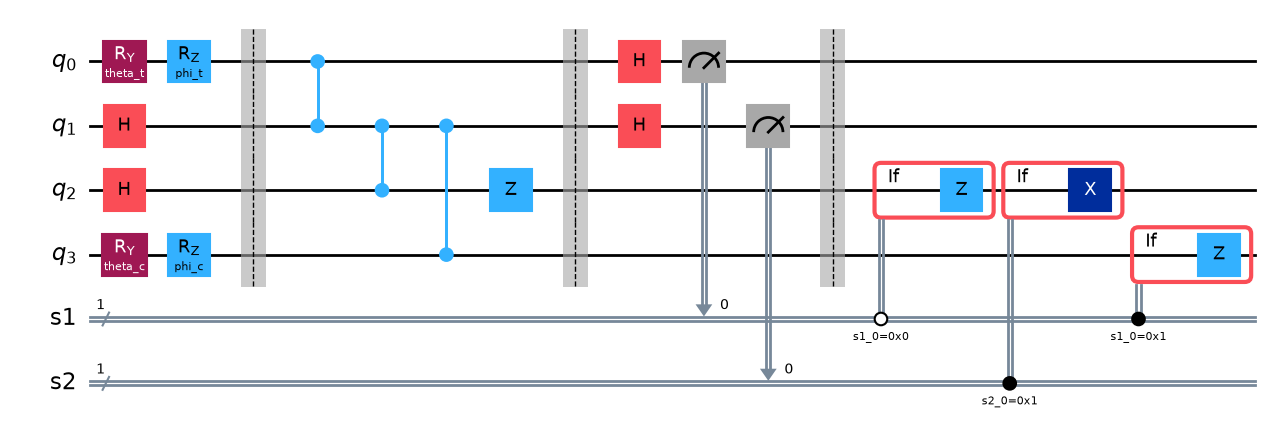

In [3]:
# Visualizza il circuito dinamico completo.
qc.draw("mpl", fold=30)

## Parametri numerici

Il circuito contiene quattro parametri continui:

- $\theta_t,\phi_t$ preparano lo stato di ingresso del target;
- $\theta_c,\phi_c$ preparano lo stato di ingresso del controllo.

Scegliamo valori generici in modo che entrambi i qubit abbiano ampiezze di sovrapposizione e fasi non nulle.  
L'uscita ideale della CNOT sarà quindi, in generale, uno stato a due qubit entangled.

In [4]:
import numpy as np

params = {p.name: p for p in qc.parameters}

theta_t_value = np.pi / 3
phi_t_value = np.pi / 5

theta_c_value = np.pi / 4
phi_c_value = -np.pi / 6

qc_bound = qc.assign_parameters({
    params["theta_t"]: theta_t_value,
    params["phi_t"]: phi_t_value,
    params["theta_c"]: theta_c_value,
    params["phi_c"]: phi_c_value,
})

print("Parametri rimanenti:", qc_bound.parameters)

Parametri rimanenti: ParameterView([])


## Verifica dell'uscita a due qubit

Dopo le misure e le correzioni tramite feed-forward, i qubit logici di uscita sono

- $q[2]$: target di uscita $t_{\mathrm{out}}$;
- $q[3]$: controllo.

Un singolo vettore di Bloch non è più sufficiente, perché la CNOT può generare entanglement tra i due qubit di uscita.  
Ricostruiamo quindi la matrice di densità a due qubit mediante tomografia di Pauli.

Per due qubit,

$$
\rho
=
\frac{1}{4}
\sum_{P,Q\in\{I,X,Y,Z\}}
\langle Q\otimes P\rangle\,
(Q\otimes P),
$$

dove, nell'ordinamento matriciale di Qiskit, la Pauli più a destra agisce sul target e quella più a sinistra sul controllo.

Sono sufficienti nove configurazioni di misura,

$$
(P,Q)\in\{X,Y,Z\}^2,
$$

per stimare tutte le componenti locali dei singoli qubit e tutte le correlazioni a due qubit.

In [5]:
OUTPUT_TARGET = 2   # paper qubit 3
OUTPUT_CONTROL = 3  # paper qubit 4

def apply_measurement_basis(circuit, qubit, basis):
    # Ruota la misura X, Y o Z nella base computazionale.
    if basis == "X":
        circuit.h(qubit)
    elif basis == "Y":
        circuit.sdg(qubit)
        circuit.h(qubit)
    elif basis != "Z":
        raise ValueError("basis must be 'X', 'Y', or 'Z'")


def circuit_for_two_qubit_measurement(circuit, target_basis, control_basis):
    # Restituisce una copia che misura le due uscite logiche nelle basi di Pauli scelte.
    measured = circuit.copy()

    tag = f"{target_basis.lower()}{control_basis.lower()}"
    out_t = ClassicalRegister(1, f"out_t_{tag}")
    out_c = ClassicalRegister(1, f"out_c_{tag}")
    measured.add_register(out_t)
    measured.add_register(out_c)

    apply_measurement_basis(measured, OUTPUT_TARGET, target_basis)
    apply_measurement_basis(measured, OUTPUT_CONTROL, control_basis)

    measured.measure(OUTPUT_TARGET, out_t[0])
    measured.measure(OUTPUT_CONTROL, out_c[0])

    idx_t = measured.find_bit(out_t[0]).index
    idx_c = measured.find_bit(out_c[0]).index

    return measured, idx_t, idx_c


measurement_circuits = {}
output_indices = {}

for target_basis in "XYZ":
    for control_basis in "XYZ":
        key = (target_basis, control_basis)
        measured, idx_t, idx_c = circuit_for_two_qubit_measurement(
            qc_bound,
            target_basis,
            control_basis,
        )
        measurement_circuits[key] = measured
        output_indices[key] = (idx_t, idx_c)

## Simulazione

Il circuito contiene misure intermedie e controllo classico, quindi i nove circuiti necessari alla tomografia vengono traspilati per `AerSimulator` ed eseguiti con un numero finito di *shots*.

Come nel notebook dedicato al singolo qubit, i risultati precedenti $s_1,s_2$ rimangono presenti nei conteggi grezzi perché sono necessari al feed-forward.  
Durante la ricostruzione dello stato logico di uscita vengono marginalizzati.

In [6]:
from qiskit import transpile
from qiskit_aer import AerSimulator

sim = AerSimulator()
shots = 20_000

keys = list(measurement_circuits)
circuits = [measurement_circuits[key] for key in keys]

transpiled = transpile(circuits, sim)
result = sim.run(transpiled, shots=shots).result()

counts = {
    key: result.get_counts(i)
    for i, key in enumerate(keys)
}

In [7]:
# Mostra alcune voci grezze per la configurazione X-X.
from pprint import pprint

pprint(list(counts[("X", "X")].items())[:10])

[('0 1 0 0', 136),
 ('0 0 0 1', 3491),
 ('1 1 1 1', 604),
 ('1 0 1 1', 842),
 ('0 0 1 1', 3400),
 ('0 1 1 1', 147),
 ('0 0 1 0', 3344),
 ('0 0 0 0', 3482),
 ('1 1 0 1', 601),
 ('1 1 1 0', 610)]


Una chiave dei conteggi grezzi contiene i due bit finali di uscita insieme ai registri di misura precedenti $s_1$ e $s_2$.  
Per la tomografia servono soltanto i bit di uscita: i risultati delle misure MBQC hanno già svolto il loro ruolo attraverso le correzioni condizionali.

## Valori di aspettazione marginali

Per una singola misura di Pauli con risultati $0$ e $1$,

$$
\langle P\rangle
=
\frac{N_0-N_1}{N_0+N_1}.
$$

Per un prodotto di Pauli a due qubit $Q\otimes P$, l'autovalore è $+1$ quando i due bit di uscita hanno parità pari e $-1$ quando hanno parità dispari. Pertanto

$$
\langle Q\otimes P\rangle
=
\frac{N_{\mathrm{pari}}-N_{\mathrm{dispari}}}
     {N_{\mathrm{pari}}+N_{\mathrm{dispari}}}.
$$

In [8]:
from qiskit.result import marginal_counts

def expectation_single(binary_counts):
    # Stima <P> dai conteggi a un bit.
    n0 = binary_counts.get("0", 0)
    n1 = binary_counts.get("1", 0)
    return (n0 - n1) / (n0 + n1)


def expectation_parity(binary_counts):
    # Stima un prodotto di Pauli a due qubit dalla parità delle uscite.
    even = 0
    odd = 0

    for bitstring, n in binary_counts.items():
        bits = bitstring.replace(" ", "")
        parity = sum(int(bit) for bit in bits) % 2

        if parity == 0:
            even += n
        else:
            odd += n

    return (even - odd) / (even + odd)


target_local = {}
control_local = {}
correlations = {}

# Ogni valore di aspettazione locale è disponibile in tre diverse configurazioni congiunte.
# La media delle tre stime riduce il rumore di campionamento.
for P in "XYZ":
    estimates = []

    for Q in "XYZ":
        idx_t, _ = output_indices[(P, Q)]
        mt = marginal_counts(counts[(P, Q)], indices=[idx_t])
        estimates.append(expectation_single(mt))

    target_local[P] = float(np.mean(estimates))


for Q in "XYZ":
    estimates = []

    for P in "XYZ":
        _, idx_c = output_indices[(P, Q)]
        mc = marginal_counts(counts[(P, Q)], indices=[idx_c])
        estimates.append(expectation_single(mc))

    control_local[Q] = float(np.mean(estimates))


for P in "XYZ":
    for Q in "XYZ":
        idx_t, idx_c = output_indices[(P, Q)]
        joint = marginal_counts(
            counts[(P, Q)],
            indices=[idx_t, idx_c],
        )
        correlations[(P, Q)] = expectation_parity(joint)


print("Valori di aspettazione locali del target:")
for P in "XYZ":
    print(f"<{P}_t> = {target_local[P]: .6f}")

print("\nValori di aspettazione locali del controllo:")
for Q in "XYZ":
    print(f"<{Q}_c> = {control_local[Q]: .6f}")

Valori di aspettazione locali del target:
<X_t> =  0.700267
<Y_t> =  0.358533
<Z_t> =  0.359633

Valori di aspettazione locali del controllo:
<X_c> =  0.427733
<Y_c> = -0.243933
<Z_c> =  0.709500


## Ricostruzione della matrice di densità

Utilizzando i coefficienti di Pauli misurati,

$$
\rho_{\mathrm{lin}}
=
\frac14
\left[
I\otimes I
+
\sum_P \langle I\otimes P\rangle\,I\otimes P
+
\sum_Q \langle Q\otimes I\rangle\,Q\otimes I
+
\sum_{P,Q}\langle Q\otimes P\rangle\,Q\otimes P
\right].
$$

Le fluttuazioni dovute al numero finito di *shots* possono rendere leggermente non positiva una stima ottenuta tramite inversione lineare.  
Come piccola correzione numerica, gli autovalori negativi vengono posti uguali a zero e la matrice viene rinormalizzata prima del calcolo della fedeltà.

In [9]:
from qiskit.quantum_info import Pauli

rho_linear = np.eye(4, dtype=complex)

# Termini del target: il carattere di Pauli più a destra agisce sul qubit 0 di Qiskit
# del sistema logico di riferimento a due qubit.
for P in "XYZ":
    rho_linear += target_local[P] * Pauli("I" + P).to_matrix()

# Termini del controllo: carattere di Pauli più a sinistra.
for Q in "XYZ":
    rho_linear += control_local[Q] * Pauli(Q + "I").to_matrix()

# Correlazioni a due qubit.
for P in "XYZ":
    for Q in "XYZ":
        rho_linear += correlations[(P, Q)] * Pauli(Q + P).to_matrix()

rho_linear /= 4

# Impone l'ermiticità eliminando piccole asimmetrie numeriche.
rho_linear = (rho_linear + rho_linear.conj().T) / 2

eigenvalues, eigenvectors = np.linalg.eigh(rho_linear)

# Proietta la stima a shots finiti sul cono delle matrici semidefinite positive.
eigenvalues_physical = np.clip(eigenvalues, 0, None)
eigenvalues_physical /= eigenvalues_physical.sum()

rho_measured = (
    eigenvectors
    @ np.diag(eigenvalues_physical)
    @ eigenvectors.conj().T
)

print("Autovalori da inversione lineare:")
print(eigenvalues)

print("\nAutovalori fisici ricostruiti:")
print(np.linalg.eigvalsh(rho_measured))

Autovalori da inversione lineare:
[-0.00307105 -0.00127149  0.00806743  0.99627511]

Autovalori fisici ricostruiti:
[-1.27822074e-17  5.09461238e-17  8.03255166e-03  9.91967448e-01]


## Stato teorico di riferimento

Il calcolo di riferimento è indipendente dall'implementazione MBQC.

Prepariamo gli stessi stati di target e controllo in un normale circuito a due qubit e applichiamo una CNOT standard con il controllo sul qubit logico $1$ e il target sul qubit logico $0$:

$$
|\psi_{\mathrm{ideal}}\rangle
=
\mathrm{CNOT}_{c\to t}
\left(
|\psi_c\rangle\otimes|\psi_t\rangle
\right).
$$

La matrice di densità ricostruita tramite MBQC deve concordare con questo stato ideale entro le fluttuazioni statistiche dovute al numero finito di *shots*.

In [10]:
from qiskit.quantum_info import Statevector, DensityMatrix

# Ordinamento logico di riferimento:
# qubit di riferimento 0 = target
# qubit di riferimento 1 = controllo
reference = QuantumCircuit(2)

reference.ry(theta_t_value, 0)
reference.rz(phi_t_value, 0)

reference.ry(theta_c_value, 1)
reference.rz(phi_c_value, 1)

reference.cx(1, 0)

psi_theory = Statevector.from_instruction(reference)
rho_theory = DensityMatrix(psi_theory).data

print("Vettore di stato ideale in uscita:")
print(psi_theory.data)

Vettore di stato ideale in uscita:
[0.79900663-0.04187416j 0.38741529+0.25159043j 0.19107949+0.01001405j
 0.27794681-0.18050077j]


## Confronto dei coefficienti di Pauli

La tomografia può essere verificata direttamente confrontando tutti i 15 coefficienti di Pauli non banali del sistema a due qubit.

Per una matrice di densità ideale $\rho_{\mathrm{th}}$,

$$
\langle A\rangle_{\mathrm{th}}
=
\operatorname{Tr}(\rho_{\mathrm{th}}A).
$$

Con $N=2\times10^4$ *shots* per ciascuna base congiunta, differenze dell'ordine di $10^{-2}$ sono compatibili con le normali fluttuazioni dovute al campionamento finito.

In [11]:
def theoretical_expectation(label):
    operator = Pauli(label).to_matrix()
    return float(np.real(np.trace(rho_theory @ operator)))


rows = []

for P in "XYZ":
    measured = target_local[P]
    theory = theoretical_expectation("I" + P)
    rows.append((f"I{P}", measured, theory, abs(measured - theory)))

for Q in "XYZ":
    measured = control_local[Q]
    theory = theoretical_expectation(Q + "I")
    rows.append((f"{Q}I", measured, theory, abs(measured - theory)))

for P in "XYZ":
    for Q in "XYZ":
        measured = correlations[(P, Q)]
        theory = theoretical_expectation(Q + P)
        rows.append((f"{Q}{P}", measured, theory, abs(measured - theory)))

print("Pauli    misurato       teorico            |errore|")
for label, measured, theory, error in rows:
    print(f"{label:>4}    {measured: .6f}      {theory: .6f}      {error:.6f}")

print("\nErrore massimo sui coefficienti di Pauli:",
      max(error for _, _, _, error in rows))

Pauli    misurato       teorico            |errore|
  IX     0.700267       0.700629      0.000363
  IY     0.358533       0.359943      0.001410
  IZ     0.359633       0.353553      0.006080
  XI     0.427733       0.429046      0.001313
  YI    -0.243933      -0.247710      0.003777
  ZI     0.709500       0.707107      0.002393
  XX     0.612500       0.612372      0.000128
  YX    -0.339300      -0.353553      0.014253
  ZX     0.492000       0.495420      0.003420
  XY    -0.184500      -0.176777      0.007723
  YY    -0.306000      -0.306186      0.000186
  ZY     0.500300       0.509037      0.008737
  XZ     0.176100       0.179972      0.003872
  YZ     0.303600       0.311720      0.008120
  ZZ     0.492900       0.500000      0.007100

Errore massimo sui coefficienti di Pauli: 0.01425339059327374


## Fedeltà

Poiché lo stato teorico di riferimento è puro, la fedeltà può essere valutata direttamente come

$$
F
=
\langle\psi_{\mathrm{ideal}}|
\rho_{\mathrm{meas}}
|\psi_{\mathrm{ideal}}\rangle.
$$

Calcoliamo anche la purezza

$$
\operatorname{Tr}(\rho_{\mathrm{meas}}^2),
$$

che tende a $1$ quando lo stato ricostruito è puro.

In [12]:
psi = psi_theory.data

fidelity = float(np.real(
    np.vdot(psi, rho_measured @ psi)
))

purity = float(np.real(
    np.trace(rho_measured @ rho_measured)
))

delta = rho_measured - rho_theory
trace_distance = 0.5 * float(
    np.sum(np.abs(np.linalg.eigvalsh(delta)))
)

print("Fedeltà         =", fidelity)
print("Purezza          =", purity)
print("Distanza di traccia =", trace_distance)

Fedeltà         = 0.9919447185778997
Purezza          = 0.98406394045745
Distanza di traccia = 0.010174323671844628


## Interpretazione

Se l'entanglement del cluster, le misure in $X$ e le correzioni tramite feed-forward sono implementati correttamente, i due qubit non misurati contengono

$$
\boxed{
|\psi_{\mathrm{out}}\rangle
=
\mathrm{CNOT}_{4\rightarrow 3}
|\psi_{\mathrm{in}}\rangle
}
$$

dopo la rimozione della correzione di Pauli.

L'informazione del target viene trasferita dal qubit fisico $1$ al qubit fisico $3$, mentre il qubit $4$ controlla se il target logico viene invertito oppure no.

Per ingressi nella base computazionale questo si riduce a

$$
|t\rangle_1|c\rangle_4
\longmapsto
|t\oplus c\rangle_3|c\rangle_4.
$$

Per ingressi in sovrapposizione, lo stesso schema agisce coerentemente e può generare entanglement. Per questo motivo la tomografia a due qubit utilizzata sopra costituisce una verifica più forte rispetto al semplice controllo delle quattro righe della tabella di verità classica della CNOT.